In [20]:
# SME Segmentation Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [22]:
# --- Load Data ---
df = pd.read_csv(r"../Data/sme_synthetic_credit_data_FULL.csv")

In [24]:
# --- Drop future/leakage features ---
leakage_cols = [
    'default_in_12_mo', 'loss_given_default', 'credit_limit',
    'collateral_value', 'collateral_type', 'archetype',
    'fraud_alert_flag', 'num_defaults_last_12mo'
]
segmentation_features = [col for col in df.columns if col not in leakage_cols]

In [26]:
# --- Encode Categorical Columns ---
categorical_cols = df[segmentation_features].select_dtypes(include='object').columns
# Save label encoders per categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Fit scaler
scaler = StandardScaler()
X_seg = scaler.fit_transform(df[segmentation_features])

# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_seg)

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_seg)
df['risk_cluster'] = clusters

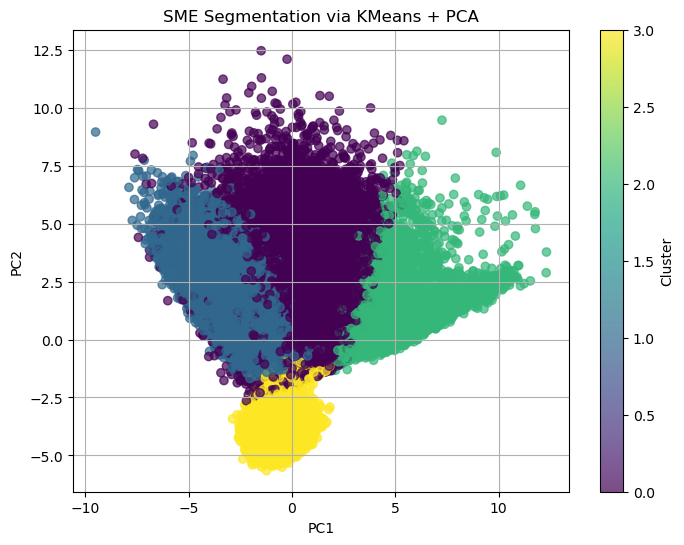

In [28]:
# --- Visualization ---
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.title("SME Segmentation via KMeans + PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [30]:
# --- Cluster Profiling ---
cluster_summary = df.groupby('risk_cluster')[segmentation_features].mean()
print("\nCluster Summary:\n")
print(cluster_summary.round(2))


Cluster Summary:

              monthly_revenue  monthly_expenses  net_profit_margin  \
risk_cluster                                                         
0                   712593.66         891831.18              -0.25   
1                  1058421.67         794068.43               0.25   
2                   107521.09         112781.09               0.01   
3                   201530.36          80896.17               0.60   

              interest_coverage_ratio  revenue_trend_3mo  profit_trend_3mo  \
risk_cluster                                                                 
0                               -1.51               0.09              0.09   
1                                2.12               0.04              0.04   
2                               -0.00              -0.04             -0.04   
3                                5.36               0.05              0.05   

              cash_on_hand  receivables_total  payables_total  \
risk_cluster              

In [32]:
# --- Cluster Quality Metric ---
sil_score = silhouette_score(X_seg, clusters)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.4061


C:\Users\Orjouwen\AppData\Local\Temp\ipykernel_1536\3519887559.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_cluster', y=feature, data=df, palette='Set2')


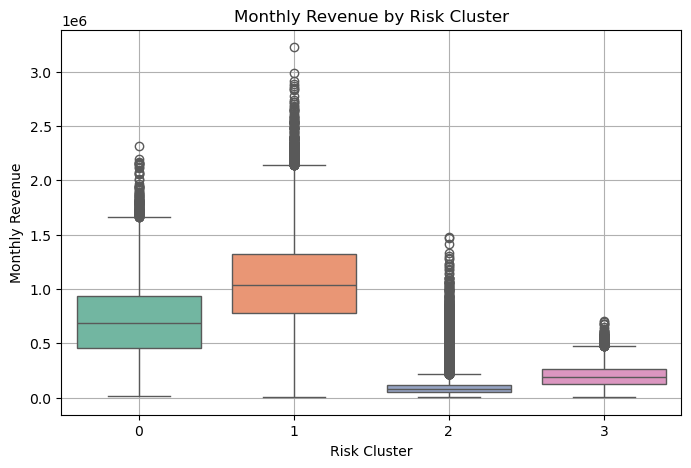

C:\Users\Orjouwen\AppData\Local\Temp\ipykernel_1536\3519887559.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_cluster', y=feature, data=df, palette='Set2')


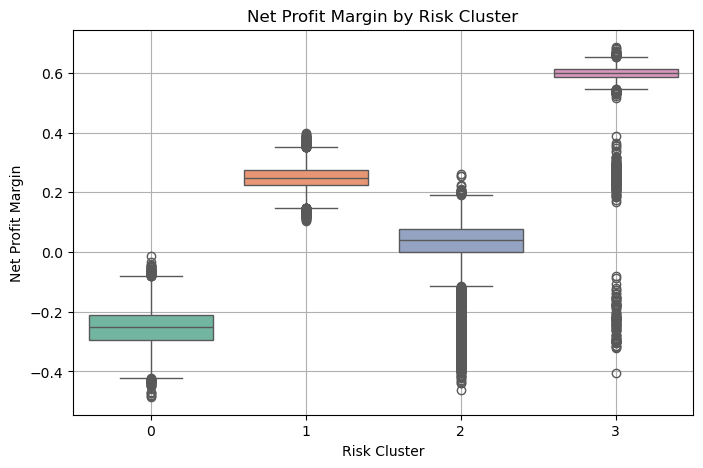

C:\Users\Orjouwen\AppData\Local\Temp\ipykernel_1536\3519887559.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_cluster', y=feature, data=df, palette='Set2')


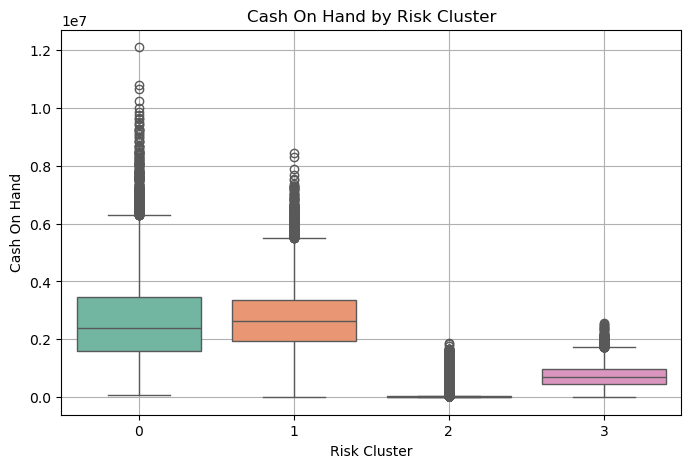

C:\Users\Orjouwen\AppData\Local\Temp\ipykernel_1536\3519887559.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_cluster', y=feature, data=df, palette='Set2')


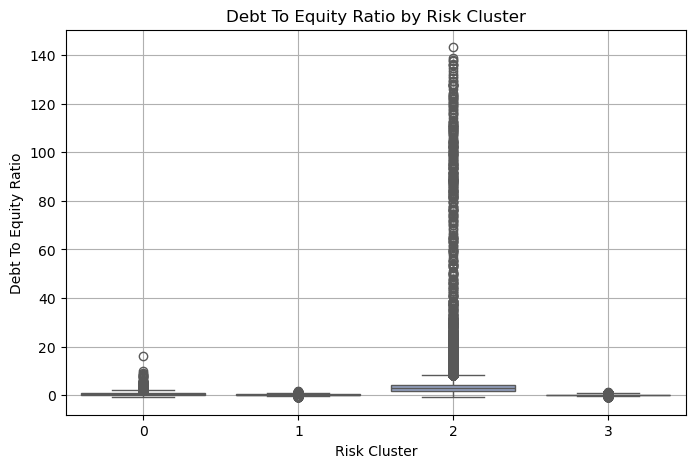

C:\Users\Orjouwen\AppData\Local\Temp\ipykernel_1536\3519887559.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_cluster', y=feature, data=df, palette='Set2')


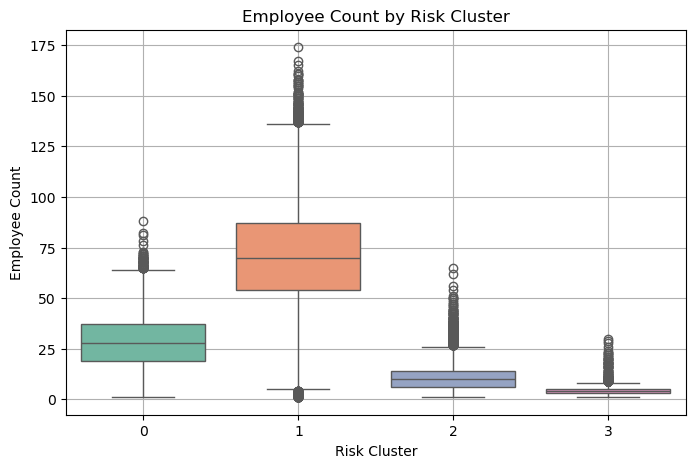

In [33]:
key_features = ['monthly_revenue', 'net_profit_margin', 'cash_on_hand', 'debt_to_equity_ratio', 'employee_count']

for feature in key_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='risk_cluster', y=feature, data=df, palette='Set2')
    plt.title(f"{feature.replace('_', ' ').title()} by Risk Cluster")
    plt.xlabel("Risk Cluster")
    plt.ylabel(feature.replace('_', ' ').title())
    plt.grid(True)
    plt.show()

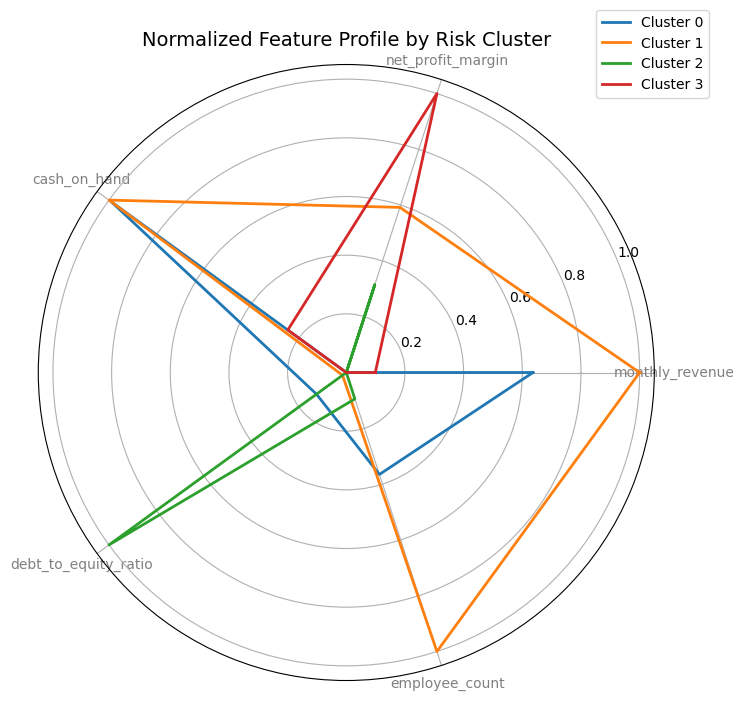

In [34]:
from math import pi

radar_data = cluster_summary[key_features].copy()
radar_data = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())  # Normalize for plotting
labels = radar_data.columns.tolist()

plt.figure(figsize=(8, 8))
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # complete the loop

for idx, row in radar_data.iterrows():
    values = row.tolist()
    values += values[:1]  # complete the loop
    plt.polar(angles, values, label=f"Cluster {idx}", linewidth=2)

plt.xticks(angles[:-1], labels, color='gray')
plt.title("Normalized Feature Profile by Risk Cluster", size=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.grid(True)
plt.show()


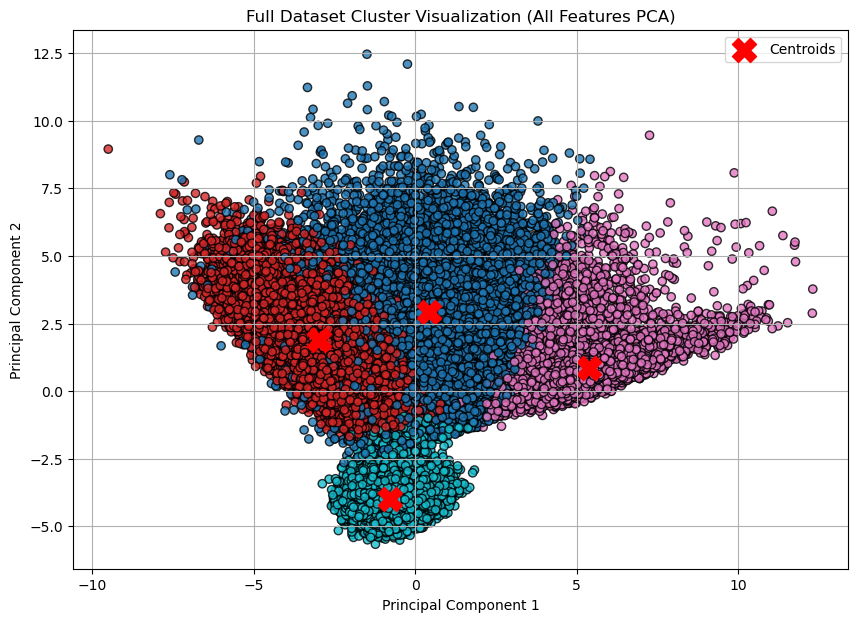

In [35]:
# --- All Features 2D Projection ---
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', edgecolor='k', alpha=0.8)
centroids_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title("Full Dataset Cluster Visualization (All Features PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
import joblib
joblib.dump({
    "label_encoders": label_encoders,
    "scaler": scaler,
    "pca": pca,
    "kmeans": kmeans,
    "features": segmentation_features
}, 'segmentation_pipeline.pkl')

['segmentation_pipeline.pkl']